# iCorrVision 2.0: API tour

This notebook drives the correlation engine directly from Python: no GUI, no CLI, no TOML file. A run is *declared* by building a few configuration objects, and executed by one call.

Every section uses synthetic images with an exactly known deformation (`synthetic.py`, next to this notebook), so each one ends by **checking** the engine's answer against the truth. Run from a clean kernel, the notebook stops at the first failed check, which makes it both the API's documentation and executable evidence that the API works.

| Section | Shows |
|---|---|
| 1 | The minimal run: known sub-pixel shift in, measured shift out |
| 2 | Strain: a known uniform deformation, two strain estimators, the virtual strain gauge |
| 3 | Configuration as data: sweeping interpolants by editing configs |
| 4 | Invalid configurations are rejected before anything runs |
| 5 | Files in, files out: a folder of TIFFs, CSV export, `.icorr` archive round-trip |
| 6 | Extending the engine: a new interpolator, registered without touching pipeline code |

Each section builds its own inputs, so any one of them can be read, or copied, on its own.

## Setup

The first line blocks PySide6 for the whole kernel. Python keeps every imported module in `sys.modules`; an entry set to `None` makes any later `import PySide6` fail. If this notebook runs to the end, the engine's entire public API was loaded and used without Qt.

Everything else comes from `icorrvision`, the engine's public API. Nothing is imported from `components` directly: the internal layout can change, the names in `icorrvision.__all__` cannot.

In [1]:
import sys
sys.modules["PySide6"] = None   # any Qt import from here on raises ImportError

import dataclasses
import tempfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

import icorrvision as ic
from synthetic import affine_warp, green_lagrange, speckle, translate

print("icorrvision", ic.__version__, "-", len(ic.__all__), "public names")

icorrvision 2.0.0 - 39 public names


## 1. The minimal run

Three objects describe a run:

- **`SetupOutput`**: the *what*. The reference image, the region of interest, the subset and step sizes, and the
  names of the deformed frames.
- **`CorrelationConfig`**: the *how*. One choice per algorithmic stage; every field has a default.
- **a frame loader**: any function that takes a frame name and returns the image. The engine asks for frames one
  at a time, by name, so a sequence never has to fit in memory at once.

Here the frames already sit in a dictionary, and its lookup method, `frames.__getitem__`, is such a function:
it maps a name to an image.

`build_engine` checks the configuration and assembles the engine; `.run()` correlates every deformed frame.

In [2]:
reference = speckle(seed=0)
frames = {"shifted": translate(reference, dx=1.6, dy=-0.9)}

setup = ic.SetupOutput(
    reference_frame=reference,
    roi_mask=np.ones(reference.shape, dtype=bool),  # whole image
    subset_size=21,
    step_size=8,
    deformed_list=["shifted"],
)
config = ic.CorrelationConfig(
    search_size=31,
    image_interpolation=ic.InterpolationConfig("biquintic_spline"),
)

result = ic.build_engine(config, setup, frames.__getitem__).run()

`result.frames[0]` is the reference; `result.frames[1]` is the first deformed frame. Every field is a 2D array over
the node grid, and `valid_mask` marks nodes that correlated. Nodes near the border are invalid by design: their
search window would leave the image.

In [3]:
frame = result.frames[1]
valid = frame.valid_mask
u, v = frame.u_px[valid], frame.v_px[valid]

print(f"valid nodes : {valid.sum()} of {valid.size} ({valid.mean():.0%})")
print(f"u           : {u.mean():+.5f} px  (imposed +1.6), max error {np.abs(u - 1.6).max():.5f} px")
print(f"v           : {v.mean():+.5f} px  (imposed -0.9), max error {np.abs(v + 0.9).max():.5f} px")

assert valid.mean() > 0.8
assert abs(u.mean() - 1.6) < 0.005 and abs(v.mean() + 0.9) < 0.005
assert np.abs(u - 1.6).max() < 0.02 and np.abs(v + 0.9).max() < 0.02

valid nodes : 784 of 900 (87%)
u           : +1.60010 px  (imposed +1.6), max error 0.00194 px
v           : -0.90004 px  (imposed -0.9), max error 0.00212 px


## 2. Strain from a known deformation

`affine_warp` applies a uniform displacement gradient, so the Green–Lagrange strain is the same everywhere and known
in closed form. Two strain estimators are compared on the same displacement field:

- **`lagrange_q4`**: a bilinear polynomial fitted over a square window of `strain_window` *grid nodes*;
- **`lagrange_cloud`**: a plane fitted to all nodes within `radius_px` *pixels*.

They are set up with the same virtual strain gauge (VSG), the image extent each strain value averages over,
so the comparison is fair. The engine does not compute the VSG; the small helper below does, for either estimator:
windowed `(SW − 1)·ST + SS`, meshfree `2r + SS`.

`dataclasses.replace` makes a *copy* of a frozen config with some fields changed. Frozen configs cannot be edited
in place; replacing is how one declared run becomes another.

In [4]:
def vsg_px(strain, subset_size, step_size):
    # Virtual strain gauge: the image extent, in px, that each strain value averages over.
    if strain.method == "lagrange_cloud":
        return 2.0 * strain.radius_px + subset_size                   # disc of radius r, plus one subset
    return float((strain.strain_window - 1) * step_size + subset_size)  # window of nodes, plus one subset


reference = speckle(seed=0)
exx, eyy, exy = 0.02, -0.01, 0.005
E_true = green_lagrange(exx, eyy, exy)
frames = {"stretched": affine_warp(reference, exx, eyy, exy)}

setup = ic.SetupOutput(
    reference_frame=reference,
    roi_mask=np.ones(reference.shape, dtype=bool),
    subset_size=21,
    step_size=6,
    deformed_list=["stretched"],
)
base = ic.CorrelationConfig(
    search_size=41,   # the corners move by ~2.5 px; the window must contain that
    image_interpolation=ic.InterpolationConfig("biquintic_spline"),
)

estimators = {
    "Q4, 7-node window": ic.StrainConfig("lagrange_q4", strain_window=7),
    "meshfree, r = 18 px": ic.StrainConfig("lagrange_cloud", radius_px=18.0),
}
strain_results = {}
for name, strain in estimators.items():
    run = ic.build_engine(dataclasses.replace(base, strain=strain), setup, frames.__getitem__).run()
    strain_results[name] = run.frames[1].strain
    print(f"{name:20s} VSG = {vsg_px(strain, setup.subset_size, setup.step_size):.0f} px")

# The comparison is only fair if both estimators average over the same extent.
vsgs = {vsg_px(s, setup.subset_size, setup.step_size) for s in estimators.values()}
assert len(vsgs) == 1, f"estimators are not at matched VSG: {sorted(vsgs)}"

Q4, 7-node window    VSG = 57 px
meshfree, r = 18 px  VSG = 57 px


truth (Green-Lagrange): Exx +0.020212  Eyy -0.009937  Exy +0.005025

Q4, 7-node window    1296 nodes, max |error| Exx 4.5e-05  Eyy 4.1e-05  Exy 4.5e-05
meshfree, r = 18 px  1296 nodes, max |error| Exx 4.4e-05  Eyy 4.9e-05  Exy 3.7e-05


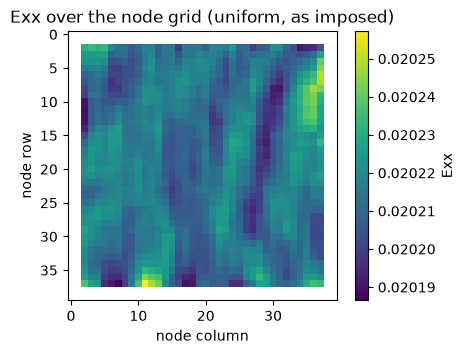

In [5]:
print(f"truth (Green-Lagrange): Exx {E_true[0]:+.6f}  Eyy {E_true[1]:+.6f}  Exy {E_true[2]:+.6f}\n")
for name, s in strain_results.items():
    fitted = np.isfinite(s.exx)
    errors = [np.abs(getattr(s, c)[fitted] - t).max() for c, t in zip(("exx", "eyy", "exy"), E_true)]
    print(f"{name:20s} {fitted.sum()} nodes, max |error| Exx {errors[0]:.1e}  Eyy {errors[1]:.1e}  Exy {errors[2]:.1e}")
    assert fitted.sum() > 100
    assert max(errors) < 1e-3

fig, ax = plt.subplots(figsize=(4.5, 3.5))
shown = ax.imshow(strain_results["Q4, 7-node window"].exx, cmap="viridis")
fig.colorbar(shown, ax=ax, label="Exx")
ax.set_title("Exx over the node grid (uniform, as imposed)")
ax.set_xlabel("node column"); ax.set_ylabel("node row")
plt.show()

## 3. Configuration as data

Because a run is fully described by its config objects, a parameter study is an ordinary loop. This one sweeps the
image interpolant over a rigid shift that walks from 0 to 1 px in steps of 0.1 px, the design of DIC Challenge
Sample 3. Interpolation bias shows up as an error that varies with the fractional part of the shift.

The shifted images are made by a Fourier shift, which involves no interpolation kernel, so the bias measured here
belongs to the engine's interpolant alone. The images are noise-free, so the error is bias alone.

In [6]:
reference = speckle(seed=1)
shifts = np.round(np.arange(0.0, 1.01, 0.1), 2)
frames = {f"shift_{s:.1f}": translate(reference, dx=s, dy=s) for s in shifts}

setup = ic.SetupOutput(
    reference_frame=reference,
    roi_mask=np.ones(reference.shape, dtype=bool),
    subset_size=21,
    step_size=10,
    deformed_list=list(frames),
)
base = ic.CorrelationConfig(search_size=27)


def bias_curve(config):
    # Mean measured u minus imposed shift, one value per deformed frame.
    run = ic.build_engine(config, setup, frames.__getitem__).run()
    return np.array([f.u_px[f.valid_mask].mean() - s for f, s in zip(run.frames[1:], shifts)])


bias = {}
for method in ("8tap", "bicubic_spline", "biquintic_spline"):
    config = dataclasses.replace(base, image_interpolation=ic.InterpolationConfig(method))
    bias[method] = bias_curve(config)
    print(f"{method:17s} peak |bias| = {np.abs(bias[method]).max():.5f} px")

8tap              peak |bias| = 0.00669 px
bicubic_spline    peak |bias| = 0.00009 px
biquintic_spline  peak |bias| = 0.00011 px


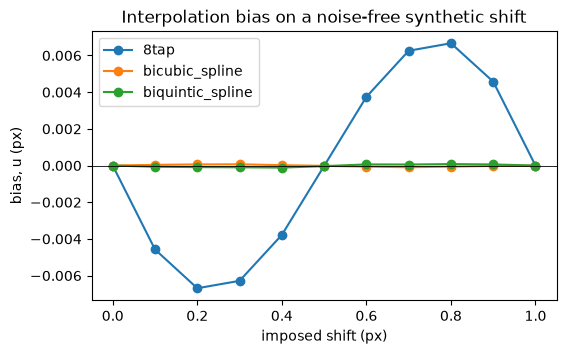

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for method, curve in bias.items():
    ax.plot(shifts, curve, marker="o", label=method)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("imposed shift (px)")
ax.set_ylabel("bias, u (px)")
ax.set_title("Interpolation bias on a noise-free synthetic shift")
ax.legend()
plt.show()

# The normalised Lanczos-4 kernel ("8tap") does not reproduce linear intensity ramps exactly, so it carries a
# sinusoidal bias; the B-splines reproduce polynomials up to their degree and stay near zero.
assert np.abs(bias["biquintic_spline"]).max() < 0.002
assert np.abs(bias["8tap"]).max() > 5 * np.abs(bias["biquintic_spline"]).max()

The same loop answers a question about the correlation criterion. ZNSSD, normalised as the engine reports it, equals
ZNCC exactly (C_ZNSSD = 2(1 − C_ZNCC)), so exchanging one for the other leaves every result unchanged. The criterion
stage is substitutable, but its two implementations are mathematically the same measure.

In [8]:
quintic = dataclasses.replace(base, image_interpolation=ic.InterpolationConfig("biquintic_spline"))
runs = {
    name: ic.build_engine(dataclasses.replace(quintic, criterion_name=name), setup, frames.__getitem__).run()
    for name in ("zncc", "znssd")
}
largest = max(
    np.nanmax(np.abs(a.u_px - b.u_px)) for a, b in zip(runs["zncc"].frames, runs["znssd"].frames)
)
print(f"largest |u(ZNCC) - u(ZNSSD)| over all frames and nodes: {largest:.1e} px")
assert largest < 1e-12

largest |u(ZNCC) - u(ZNSSD)| over all frames and nodes: 0.0e+00 px


The coarse search stage can be swapped in the same way. The pyramid search reaches its integer-pixel estimate
through down-sampled copies of the images instead of scanning every offset, but it hands the same kind of
estimate to the same refinement. Where both strategies find a node, the refined displacement must be identical;
the pyramid loses a few nodes near the image border, where its coarser crops leave the image first.

In [9]:
pyramid = dataclasses.replace(quintic, search=ic.SearchConfig(method="pyramid", pyramid_levels=2))
by_search = {
    "brute": ic.build_engine(quintic, setup, frames.__getitem__).run(),
    "pyramid": ic.build_engine(pyramid, setup, frames.__getitem__).run(),
}
pairs = list(zip(by_search["brute"].frames[1:], by_search["pyramid"].frames[1:]))
both = [a.valid_mask & b.valid_mask for a, b in pairs]
largest = max(np.abs(a.u_px[m] - b.u_px[m]).max() for (a, b), m in zip(pairs, both))
kept = sum(m.sum() for m in both) / sum(a.valid_mask.sum() for a, _ in pairs)
print(f"largest |u(brute) - u(pyramid)| on nodes both found: {largest:.1e} px")
print(f"nodes found by the pyramid, relative to brute force: {kept:.1%}")
assert largest < 1e-12
assert kept > 0.95

largest |u(brute) - u(pyramid)| on nodes both found: 0.0e+00 px
nodes found by the pyramid, relative to brute force: 99.2%


## 4. Invalid configurations fail before anything runs

Two layers of checks exist, and both raise before a single image is correlated:

- **the config objects validate themselves** when constructed (an even subset size, an even search window, a
  Q9 strain window that is too small, incremental correlation without Lagrangian tracking), raising `ValueError`;
- **`build_engine` validates the combination**: an incomplete setup, an ROI mask the wrong size for the image,
  a search window no larger than the subset, a method name no registry knows. These raise `EngineBuildError`,
  which is itself a `ValueError`, and the message names what is wrong.

In [10]:
reference = speckle(seed=2)
good_setup = ic.SetupOutput(
    reference_frame=reference,
    roi_mask=np.ones(reference.shape, dtype=bool),
    subset_size=21,
    step_size=10,
    deformed_list=["unused"],
)
good_config = ic.CorrelationConfig(search_size=31)


def never_called(name):
    raise AssertionError("no frame should be loaded when construction fails")


construction_errors = {
    "even search window": lambda: ic.CorrelationConfig(search_size=30),
    "even subset size": lambda: ic.SetupOutput(subset_size=20, step_size=5),
    "Q9 window too small": lambda: ic.StrainConfig("lagrange_q9", strain_window=3),
    "incremental, fixed grid": lambda: ic.CorrelationConfig(search_size=31, correlation_mode="incremental"),
}
build_errors = {
    "incomplete setup": (good_config, ic.SetupOutput(reference_frame=reference, roi_mask=good_setup.roi_mask)),
    "ROI of the wrong size": (good_config, dataclasses.replace(good_setup, roi_mask=np.ones((10, 10), bool))),
    "search window = subset": (dataclasses.replace(good_config, search_size=21), good_setup),
    "unknown interpolant": (
        dataclasses.replace(good_config, image_interpolation=ic.InterpolationConfig("lanczos")),
        good_setup,
    ),
}

for case, make in construction_errors.items():
    try:
        make()
    except ValueError as err:
        print(f"{case:24s} ValueError: {err}")
    else:
        raise AssertionError(f"{case}: accepted, should have been rejected")

for case, (config, setup) in build_errors.items():
    try:
        ic.build_engine(config, setup, never_called)
    except ic.EngineBuildError as err:
        print(f"{case:24s} EngineBuildError: {err}")
    else:
        raise AssertionError(f"{case}: accepted, should have been rejected")

even search window       ValueError: search_size must be odd
even subset size         ValueError: subset_size must be a positive odd integer
Q9 window too small      ValueError: lagrange_q9 needs strain window >= 5
incremental, fixed grid  ValueError: incremental correlation requires tracking_mode='lagrangian'
incomplete setup         EngineBuildError: SetupOutput is incomplete; missing: subset_size, step_size, deformed_list
ROI of the wrong size    EngineBuildError: roi_mask shape (10, 10) does not match reference_frame shape (256, 256)
search window = subset   EngineBuildError: search_size (21) must be larger than subset_size (21)
unknown interpolant      EngineBuildError: unsupported interpolation method: 'lanczos'. Valid options: ['8tap', 'bicubic_spline', 'biquintic_spline']


## 5. Files in, files out

Real sequences live on disk. `folder_loader(path)` returns a frame loader for a folder of images, mapping a file name to
the image. It raises `FileNotFoundError` for a missing frame instead of letting a run continue without it.

Results leave the engine in two forms:

- `export_full_csv`: one row per node per frame, every field (positions, displacements in px and mm, validity,
  correlation score, all strain components);
- `write_icorr_archive`: the same CSV plus the configuration, ROI mask, thumbnails and summary plots, in one file
  the GUI can open. `read_icorr_archive` reads it back.

Everything goes into a temporary folder that is deleted at the end of the cell.

In [11]:
reference = speckle(seed=3)
images = {
    "ref.tif": reference,
    "def_01.tif": translate(reference, dx=0.5, dy=0.25),
    "def_02.tif": translate(reference, dx=1.0, dy=0.5),
}
imposed = {"def_01.tif": (0.5, 0.25), "def_02.tif": (1.0, 0.5)}

with tempfile.TemporaryDirectory() as tmp:
    folder = Path(tmp)
    for name, image in images.items():  # stored as 8-bit, like a real acquisition
        cv2.imwrite(str(folder / name), np.clip(np.round(image), 0, 255).astype(np.uint8))

    load = ic.folder_loader(folder)
    ref_image = load("ref.tif")
    setup = ic.SetupOutput(
        reference_frame=ref_image,
        roi_mask=np.ones(ref_image.shape, dtype=bool),
        subset_size=21,
        step_size=10,
        deformed_list=["def_01.tif", "def_02.tif"],
        calibration_mm_per_px=0.05,
    )
    config = ic.CorrelationConfig(search_size=27, image_interpolation=ic.InterpolationConfig("biquintic_spline"))
    result = ic.build_engine(config, setup, load).run()

    for frame in result.frames[1:]:
        dx, dy = imposed[frame.frame_name]
        u, v = frame.u_px[frame.valid_mask].mean(), frame.v_px[frame.valid_mask].mean()
        print(f"{frame.frame_name}: u {u:+.4f} px (imposed {dx}), v {v:+.4f} px (imposed {dy}), "
              f"u {frame.u_mm[frame.valid_mask].mean():.5f} mm")
        # 8-bit rounding adds a little noise, so the tolerance is looser than in section 1.
        assert abs(u - dx) < 0.01 and abs(v - dy) < 0.01

    csv_path = ic.export_full_csv(result, folder / "out" / "correlation.csv")
    archive_path = folder / "out" / "run.icorr"
    ic.write_icorr_archive(result, setup, config, load, "ref.tif", setup.deformed_list, archive_path)
    print(f"\nCSV {csv_path.stat().st_size / 1024:.0f} KB, archive {archive_path.stat().st_size / 1024:.0f} KB")

    loaded = ic.read_icorr_archive(archive_path)
    assert loaded.correlation_config == config
    for original, restored in zip(result.frames, loaded.result.frames):
        assert np.array_equal(original.valid_mask, restored.valid_mask)
        m = original.valid_mask
        assert np.allclose(original.u_px[m], restored.u_px[m], rtol=0, atol=1e-9)
    print("archive round-trip: configuration and every displacement recovered")

    try:
        load("def_99.tif")
    except FileNotFoundError as err:
        print("missing frame:", err)

def_01.tif: u +0.5000 px (imposed 0.5), v +0.2505 px (imposed 0.25), u 0.02500 mm
def_02.tif: u +0.9999 px (imposed 1.0), v +0.5001 px (imposed 0.5), u 0.05000 mm



CSV 462 KB, archive 2058 KB
archive round-trip: configuration and every displacement recovered
missing frame: Could not read image: /tmp/tmpd1q0sj39/def_99.tif


[ WARN:0@45.615] global loadsave.cpp:278 findDecoder imread_('/tmp/tmpd1q0sj39/def_99.tif'): can't open/read file: check file path/integrity


## 6. Extending the engine

Each algorithmic stage is an abstract base class, and the factory picks an implementation by name from a
**registry**, a plain dictionary. A new method is therefore two steps: subclass the stage's base class, and add
one entry to its registry. No pipeline code changes.

Here, a bilinear interpolator. `SubpixelInterpolator` asks for one method, `sample_at`: given the image window and
fractional row and column coordinates, return intensities there. The optional `prepare` hook, which precomputes
something once per window, is not needed for bilinear interpolation, so the base class default is kept.

The name `"bilinear"` is not in the `InterpolationMethodName` type alias, so a static type checker would flag the
config below; at runtime the registry is what counts.

This section comes last and removes its entry afterwards, because the registry is shared by the whole kernel.

In [12]:
from scipy.ndimage import map_coordinates


class BilinearInterpolator(ic.SubpixelInterpolator):
    # First-order interpolation: each value is a weighted mean of the four surrounding pixels.

    def sample_at(self, context, row_coords, col_coords):
        return map_coordinates(context, [row_coords, col_coords], order=1)


ic.INTERPOLATOR_REGISTRY["bilinear"] = BilinearInterpolator

reference = speckle(seed=1)
shifts = np.round(np.arange(0.0, 1.01, 0.1), 2)
frames = {f"shift_{s:.1f}": translate(reference, dx=s, dy=s) for s in shifts}
setup = ic.SetupOutput(
    reference_frame=reference,
    roi_mask=np.ones(reference.shape, dtype=bool),
    subset_size=21,
    step_size=10,
    deformed_list=list(frames),
)

peak = {}
for method in ("bilinear", "biquintic_spline"):
    config = ic.CorrelationConfig(search_size=27, image_interpolation=ic.InterpolationConfig(method))
    run = ic.build_engine(config, setup, frames.__getitem__).run()
    curve = [f.u_px[f.valid_mask].mean() - s for f, s in zip(run.frames[1:], shifts)]
    peak[method] = np.abs(curve).max()
    print(f"{method:17s} peak |bias| = {peak[method]:.5f} px")

del ic.INTERPOLATOR_REGISTRY["bilinear"]

# A first-order kernel is markedly worse than a quintic spline, which confirms that the new method is used.
assert peak["bilinear"] > 5 * peak["biquintic_spline"]
assert "bilinear" not in ic.INTERPOLATOR_REGISTRY

bilinear          peak |bias| = 0.00441 px
biquintic_spline  peak |bias| = 0.00011 px


## Summary

Everything above used only `icorrvision`, ran with PySide6 blocked, and checked its own results:

- sub-pixel displacement recovered to within a few thousandths of a pixel (section 1);
- a uniform Green–Lagrange strain recovered by two different estimators at the same VSG (section 2);
- interpolation bias measured by sweeping a config, ZNCC shown identical to ZNSSD, and the pyramid search
  shown to give the same displacements as the exhaustive one (section 3);
- invalid configurations rejected with a named reason before any correlation (section 4);
- a folder-to-archive workflow with an exact round-trip (section 5);
- a new interpolation method added and selected without modifying the pipeline (section 6).